# Blocking by an established feature — EMA indicators only (seed sweep)

Adapted from `exp3_blocking_noise_sweep.py`. There are **two colinear features** —
two noisy views of the *same* signal (`shared_signal=True`), differing only in
their noise:

- **Established feature** — pre-trained: its weight starts at the value that is
  optimal when it is the *only* feature present,
  $w^*_{\text{est}} = \text{optimal\_weight}(w^*, c_{\text{est}})$. Its noise is
  fixed at $c_{\text{est}} = 0.1$.
- **Incumbent feature** — the tracked feature from the earlier experiments: clean
  ($c = 0$), learned from a zero weight. It now has to compete with the
  established feature for the shared signal.

Because the established feature already explains part of the target, we expect it
to **partially block** the incumbent, so the incumbent's weight settles below its
solo optimum $w^*$ (the dashed reference).

Instead of sweeping the established-feature noise, this notebook fixes the noise
at $0.1$ and shows **one panel per random seed** (5 seeds total), so the run-to-run
variation is visible. Each panel is tracked on the **incumbent** feature, with a
partially transparent line for the established feature's weight. The maturity
indicators shown are **only the EMA $\Delta w$ traces** with decay rates
$\beta = 0.999$ and $\beta = 0.9999$ (the IDBD3 $-h$ indicator is dropped).

In [1]:
%matplotlib inline
import sys

# make `shared` importable regardless of the notebook's working directory
_SHARED_DIR = '/home/edan/local_projects/phd_research/phd/sandbox/feature_sifting/exploration/step_size_analysis'
if _SHARED_DIR not in sys.path:
    sys.path.insert(0, _SHARED_DIR)

import numpy as np
import matplotlib.pyplot as plt

from shared import (
    STEP_SIZE, W_COLOR, DW_COLORS,
    W_TEACHER, INCUMBENT_NOISE,
    make_problem_data, optimal_weight, run_lms_with_indicators, _norm_peak,
)

In [2]:
# --- Blocking setup: two colinear features (noisy views of the SAME signal) ---
# column 0 = established feature (pre-trained, noise EST_NOISE), column 1 = incumbent
# (clean, tracked). Only the EMA dw-traces are used as indicators here.
# The established-feature noise is fixed; we sweep the random SEED instead so the
# run-to-run variation is visible (one panel per seed).
TRACE_DECAYS_EMA = [0.999, 0.9999]   # EMA decay rates for the dw-trace indicators
EST_NOISE = 0.1                      # established-feature noise (fixed)
SEEDS = list(range(20))              # one panel per seed
N_STEPS_BLOCK = 500_000              # training steps for this experiment

results_block = {}
for seed in SEEDS:
    feats, targ = make_problem_data(
        N_STEPS_BLOCK, [W_TEACHER, 0.0], feature_noise=[EST_NOISE, INCUMBENT_NOISE],
        target_noise_std=0.1, shared_signal=True, seed=seed,
    )
    w_est0 = optimal_weight(W_TEACHER, EST_NOISE)   # established weight starts at its solo optimum
    results_block[seed] = run_lms_with_indicators(
        feats, targ, step_size=STEP_SIZE, w_init=[w_est0, 0.0],
        trace_decays=TRACE_DECAYS_EMA)

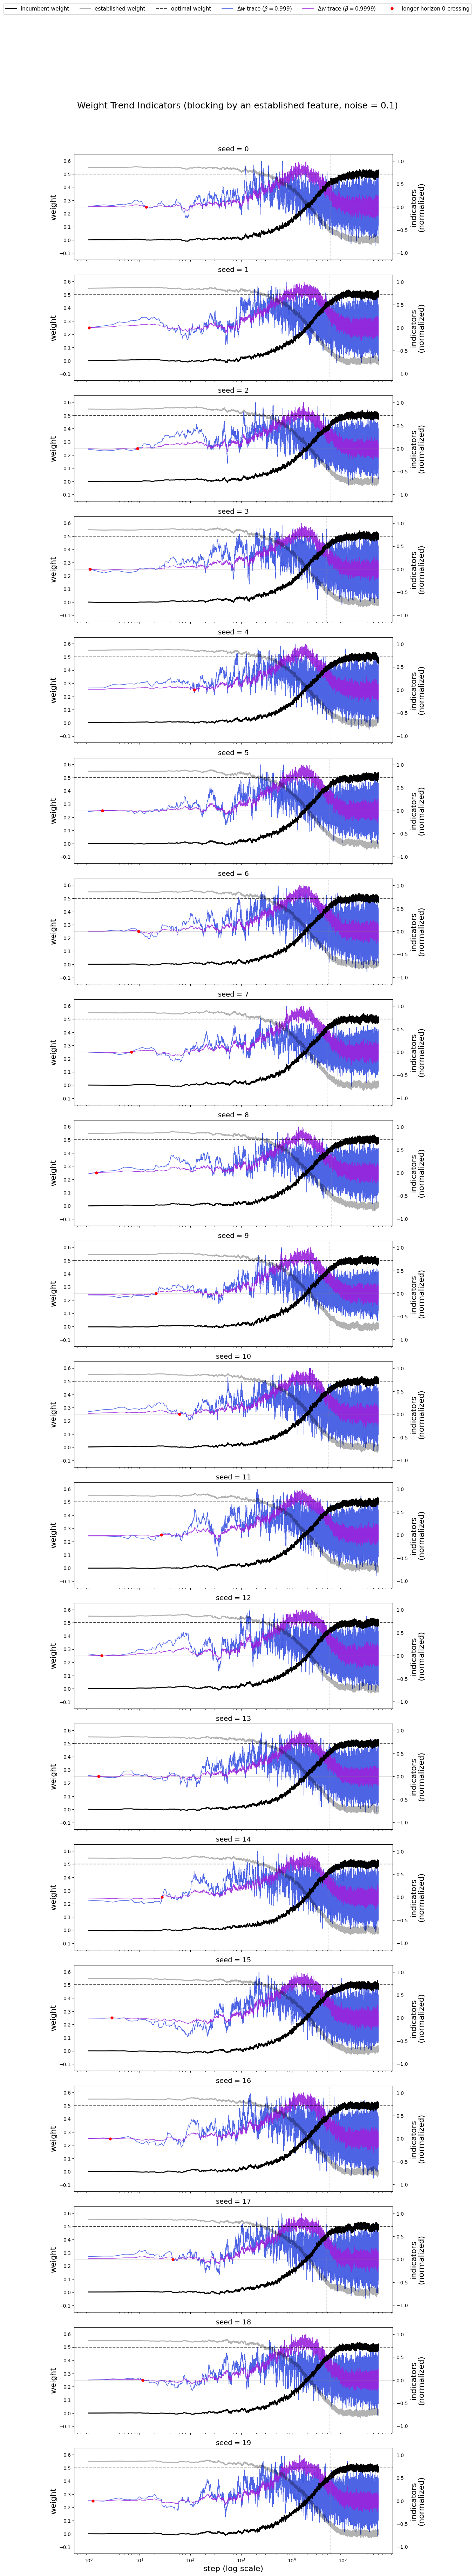

In [3]:
plot_steps = np.arange(1, N_STEPS_BLOCK + 1)
w_opt = optimal_weight(W_TEACHER, INCUMBENT_NOISE)   # clean incumbent -> equals W_TEACHER
fig, axes = plt.subplots(len(SEEDS), 1,
                         figsize=(11, 3.6 * len(SEEDS)), sharex=True,
                         squeeze=False)
axes = axes[:, 0]
ax2_first = None
for ax, seed in zip(axes, SEEDS):
    res = results_block[seed]

    # --- right axis: normalized maturity indicators (EMA dw-traces only) ---
    ax2 = ax.twinx()
    for k, d in enumerate(TRACE_DECAYS_EMA):
        ax2.plot(plot_steps, _norm_peak(res['dw_trace'][:, k]),
                 color=DW_COLORS[k], lw=1.1, alpha=0.9,
                 label=f'$\\Delta w$ trace ($\\beta = {d}$)')
    ax2.axhline(0.0, color='0.5', lw=0.6, alpha=0.3)
    ax2.set_ylim(-1.15, 1.15)
    ax2.set_ylabel('indicators\n(normalized)', fontsize=16)

    # mark where the longer-horizon EMA trace (largest decay) first crosses zero
    k_long = int(np.argmax(TRACE_DECAYS_EMA))
    norm_long = _norm_peak(res['dw_trace'][:, k_long])
    sign_change = np.where(norm_long[:-1] * norm_long[1:] < 0)[0]
    if len(sign_change):
        i = sign_change[0]
        y0, y1 = norm_long[i], norm_long[i + 1]
        x_cross = plot_steps[i] + y0 / (y0 - y1)   # interpolate (consecutive steps)
        ax2.plot(x_cross, 0.0, 'o', color='red', ms=5, zorder=20,
                 label='longer-horizon 0-crossing')

    if ax2_first is None:
        ax2_first = ax2

    # --- left axis: the weights (true scale, black) ---
    ax.plot(plot_steps, res['w'][:, -1], color=W_COLOR, lw=2.0,
            label='incumbent weight', zorder=10)
    # the established feature's weight: same scale, partially transparent
    ax.plot(plot_steps, res['w'][:, 0], color=W_COLOR, lw=2.0, alpha=0.3,
            label='established weight', zorder=10)
    ax.axhline(w_opt, color=W_COLOR, ls='--', lw=1.5, alpha=0.7,
               label='optimal weight', zorder=10)
    ax.set_xscale('log')
    ax.set_ylabel('weight', fontsize=16)
    ax.set_ylim(-w_opt * 0.3, w_opt * 1.3)
    ax.set_title(f'seed = {seed}', fontsize=14)
    ax.set_zorder(ax2.get_zorder() + 1)   # put the weight's axes above the indicator axes
    ax.patch.set_visible(False)            # but keep ax transparent so ax2 shows through

    # rough "matured" reference: incumbent first reaches 90% of its solo optimum
    if w_opt > 0:
        hit = np.where(res['w'][:, -1] >= 0.9 * w_opt)[0]
        if len(hit):
            ax.axvline(hit[0] + 1, color='0.55', ls=(0, (4, 3)), lw=1.0, alpha=0.3, zorder=10)

axes[-1].set_xlabel('step (log scale)', fontsize=16)
fig.suptitle('Weight Trend Indicators (blocking by an established feature, noise = 0.1)',
             fontsize=18)

# Build legend with left and right handles/labels
hL, lL = axes[0].get_legend_handles_labels()
hR, lR = ax2_first.get_legend_handles_labels()
legend = fig.legend(
    hL + hR, lL + lR, loc='upper center', ncol=6,
    fontsize=11, bbox_to_anchor=(0.5, 1.02),
)
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

## Reset-on-sign-flip: prune the smaller-weight feature

A single run (seed 0) that uses **only the longer trace** ($\beta = 0.9999$) of
the incumbent's weight changes. The mechanism:

- Whenever that trace **flips sign**, reset the weight of whichever feature
  currently has the **smaller magnitude** to 0 (here all weights stay positive,
  so this is just the smaller weight).
- When the feature that gets reset is the **incumbent** (the tracked one), also
  reset its trace to 0.

Early on the incumbent's weight is the smaller one, so it (and its trace) get
reset a handful of times. Once the incumbent overtakes the established feature,
the *established* feature becomes the smaller one and is repeatedly knocked back
to 0 — un-blocking the incumbent, which then climbs to its solo optimum. The rare
incumbent resets are drawn as red dots; the dense established resets are shown as
a faint vertical rug.

In [4]:
RESET_DECAY = 0.9999   # the single, longer-horizon trace used for this run
RESET_SEED = 0         # a single run


def run_lms_with_reset(features, y, step_size=STEP_SIZE, decay=RESET_DECAY, w_init=None):
    """Single-trace LMS with a competitive reset.

    Tracks ONE EMA trace (`decay`) of the incumbent feature's (last column) weight
    changes. Whenever that trace flips sign, the feature with the smaller |weight|
    is reset to 0; if that feature is the incumbent, its trace is reset to 0 too.
    """
    n_steps, n_feat = features.shape
    tracked = n_feat - 1

    w = np.zeros(n_feat) if w_init is None else np.asarray(w_init, dtype=float).copy()
    dw_tr = 0.0
    dw_tr_prev = 0.0

    w_hist = np.empty((n_steps, n_feat))
    dw_trace_hist = np.empty(n_steps)
    reset_steps, reset_incumbent = [], []

    for t in range(n_steps):
        f = features[t]
        error = float(w @ f) - y[t]              # y_hat - y  (project convention)
        dw = -step_size * (2.0 * error * f)      # LMS update for every weight
        w = w + dw
        dw_tr = decay * dw_tr + (1.0 - decay) * dw[tracked]   # EMA of tracked dw

        # reset on a sign flip of the (single, longer) weight-change trace
        if dw_tr_prev * dw_tr < 0.0:
            j = int(np.argmin(np.abs(w)))        # feature with the smaller |weight|
            w[j] = 0.0
            reset_steps.append(t)
            is_inc = (j == tracked)
            reset_incumbent.append(is_inc)
            if is_inc:
                dw_tr = 0.0                       # reset the incumbent's trace too

        dw_tr_prev = dw_tr
        w_hist[t] = w
        dw_trace_hist[t] = dw_tr

    return {'w': w_hist, 'dw_trace': dw_trace_hist,
            'reset_steps': np.asarray(reset_steps, dtype=int),
            'reset_incumbent': np.asarray(reset_incumbent, dtype=bool)}


feats_r, targ_r = make_problem_data(
    N_STEPS_BLOCK, [W_TEACHER, 0.0], feature_noise=[EST_NOISE, INCUMBENT_NOISE],
    target_noise_std=0.1, shared_signal=True, seed=RESET_SEED,
)
res_reset = run_lms_with_reset(
    feats_r, targ_r, step_size=STEP_SIZE,
    w_init=[optimal_weight(W_TEACHER, EST_NOISE), 0.0])
print('resets:', len(res_reset['reset_steps']),
      '| incumbent:', int(res_reset['reset_incumbent'].sum()),
      '| established:', int((~res_reset['reset_incumbent']).sum()))

resets: 15959 | incumbent: 7 | established: 15952


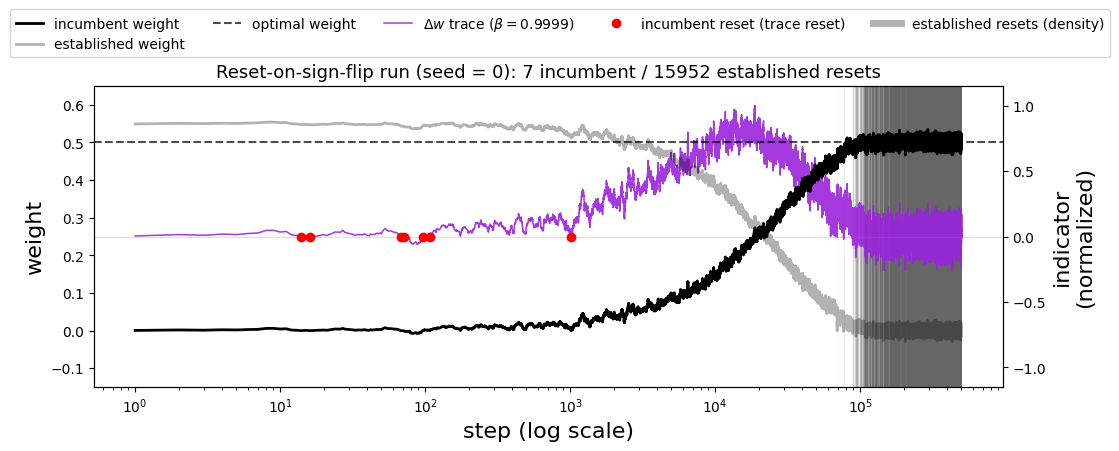

In [5]:
from matplotlib.lines import Line2D

plot_steps = np.arange(1, N_STEPS_BLOCK + 1)
w_opt = optimal_weight(W_TEACHER, INCUMBENT_NOISE)   # clean incumbent -> equals W_TEACHER
fig, ax = plt.subplots(figsize=(11, 4.2))
ax2 = ax.twinx()

# --- right axis: the single longer-horizon trace (normalized) ---
ax2.plot(plot_steps, _norm_peak(res_reset['dw_trace']), color=DW_COLORS[1],
         lw=1.1, alpha=0.9, label=f'$\\Delta w$ trace ($\\beta = {RESET_DECAY}$)')
ax2.axhline(0.0, color='0.5', lw=0.6, alpha=0.3)
ax2.set_ylim(-1.15, 1.15)
ax2.set_ylabel('indicator\n(normalized)', fontsize=16)

# reset events: established (many) as a faint density rug, incumbent (rare) as red dots
est_steps = res_reset['reset_steps'][~res_reset['reset_incumbent']] + 1
inc_steps = res_reset['reset_steps'][res_reset['reset_incumbent']] + 1
ax2.vlines(est_steps, -1.15, 1.15, color='0.4', lw=0.6, alpha=0.02, zorder=1)
ax2.plot(inc_steps, np.zeros_like(inc_steps, dtype=float), 'o', color='red',
         ms=6, zorder=20, label='incumbent reset (trace reset)')

# --- left axis: the weights (true scale, black) ---
ax.plot(plot_steps, res_reset['w'][:, -1], color=W_COLOR, lw=2.0,
        label='incumbent weight', zorder=10)
ax.plot(plot_steps, res_reset['w'][:, 0], color=W_COLOR, lw=2.0, alpha=0.3,
        label='established weight', zorder=10)
ax.axhline(w_opt, color=W_COLOR, ls='--', lw=1.5, alpha=0.7,
           label='optimal weight', zorder=10)
ax.set_xscale('log')
ax.set_ylabel('weight', fontsize=16)
ax.set_ylim(-w_opt * 0.3, w_opt * 1.3)
ax.set_xlabel('step (log scale)', fontsize=16)
ax.set_zorder(ax2.get_zorder() + 1)   # put the weight's axes above the indicator axes
ax.patch.set_visible(False)            # but keep ax transparent so ax2 shows through

n_inc = int(res_reset['reset_incumbent'].sum())
n_est = int((~res_reset['reset_incumbent']).sum())
ax.set_title(f'Reset-on-sign-flip run (seed = {RESET_SEED}): '
             f'{n_inc} incumbent / {n_est} established resets', fontsize=13)

# legend proxy so the faint established-reset rug shows up in the legend
est_proxy = Line2D([0], [0], color='0.4', lw=5, alpha=0.5,
                   label='established resets (density)')
hL, lL = ax.get_legend_handles_labels()
hR, lR = ax2.get_legend_handles_labels()
fig.legend(hL + hR + [est_proxy], lL + lR + [est_proxy.get_label()],
           loc='upper center', ncol=5, fontsize=10, bbox_to_anchor=(0.5, 1.08))
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()